In [60]:
pip install pycebox

# Week 15 Capstone (Explainable AI/SHAP interpretation)

## Predicting Pitching Performanc using Prior Season stats

### Data Extracted from Fangraphs
### By: Dylan Grim

## Step 1: Loading FanGraphs Data


In [61]:
import pandas as pd

standard = pd.DataFrame()

years = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

for year in years:

  path = f"/content/standard_pitcher_stats_{year}.csv"

  df = pd.read_csv(path)

  df['year'] = year

  standard = pd.concat([standard, df])

plus_stats = pd.DataFrame()

for year in years:
  path = f"/content/plus_pitcher_stats_{year}.csv"

  df = pd.read_csv(path)
  df['year'] = year

  plus_stats = pd.concat([plus_stats, df])

standard_columns = set(standard.columns)
plus_columns = set(plus_stats.columns)

for col in standard_columns:
  if col != 'year' and col != 'PlayerId':
    if col in plus_columns:
      plus_stats.drop(columns=[col], inplace=True)


stats = pd.merge(standard, plus_stats, on=['year', 'PlayerId'], how='inner', validate='one_to_one')
stats.head()

,Name,Team,W,L,ERA,G,GS,QS,CG,ShO,...,AVG+,WHIP+,BABIP+,LOB%+,ERA-,FIP-,xFIP-,LD%+,GB%+,FB%+
0,Max Scherzer,WSN,18,7,2.528701,33,33,28,2,1,...,77.210706,70.299853,90.626928,111.121617,61.711575,63.961433,75.147255,83.378313,77.922406,138.911353
1,Justin Verlander,HOU,16,9,2.523364,34,34,26,1,1,...,79.909874,68.734681,92.323447,117.701978,61.547311,67.446030,71.890630,92.251658,68.534923,141.116835
2,Gerrit Cole,HOU,15,5,2.875208,32,32,20,1,1,...,79.287865,78.749811,97.080876,107.514357,70.129118,65.513920,71.915754,100.932642,84.781474,117.170153
3,Jacob deGrom,NYM,10,9,1.700461,32,32,28,1,0,...,80.136309,70.420732,96.314515,112.085527,44.615312,49.275632,63.726253,100.800975,105.587487,92.315979
4,Patrick Corbin,ARI,11,7,3.150000,33,33,19,1,1,...,89.638838,81.037197,103.603837,102.151775,77.302949,61.793765,63.881418,111.871962,110.244202,79.302119


## Step 2 - Creating Target Feature

We are going to use next seasons FIP- in order to predict whether I pitcher has a good season. FIP- scales so that the MLB average sits at 100 and anything below is above average. We will set the threshold of a pitcher performing well at below 100.

In [62]:
next_year_stats = stats[['year', 'FIP-', 'PlayerId']]

# Setting feature for baseline model
stats.rename(columns={'FIP-': 'prior_season_FIP-'}, inplace=True)

stats['next_year'] = stats['year'] + 1
next_year_stats.rename(columns={'year': 'next_year'}, inplace=True)

stats = stats.merge(next_year_stats, on=['next_year', 'PlayerId'], how='inner')

stats.drop(columns=['next_year'], inplace=True)

stats['binary_fip-'] = stats['FIP-'].apply(lambda x: 1 if x < 100 else 0)
stats.drop(columns=['FIP-'], inplace=True)
stats.head()

/tmp/ipykernel_3961/2206315054.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  next_year_stats.rename(columns={'year': 'next_year'}, inplace=True)


,Name,Team,W,L,ERA,G,GS,QS,CG,ShO,...,WHIP+,BABIP+,LOB%+,ERA-,prior_season_FIP-,xFIP-,LD%+,GB%+,FB%+,binary_fip-
0,Max Scherzer,WSN,18,7,2.528701,33,33,28,2,1,...,70.299853,90.626928,111.121617,61.711575,63.961433,75.147255,83.378313,77.922406,138.911353,1
1,Justin Verlander,HOU,16,9,2.523364,34,34,26,1,1,...,68.734681,92.323447,117.701978,61.547311,67.446030,71.890630,92.251658,68.534923,141.116835,1
2,Gerrit Cole,HOU,15,5,2.875208,32,32,20,1,1,...,78.749811,97.080876,107.514357,70.129118,65.513920,71.915754,100.932642,84.781474,117.170153,1
3,Jacob deGrom,NYM,10,9,1.700461,32,32,28,1,0,...,70.420732,96.314515,112.085527,44.615312,49.275632,63.726253,100.800975,105.587487,92.315979,1
4,Patrick Corbin,ARI,11,7,3.150000,33,33,19,1,1,...,81.037197,103.603837,102.151775,77.302949,61.793765,63.881418,111.871962,110.244202,79.302119,1


## Step 3 - Dropping Invalid Rows

For this project pitchers must have at least 50 innings pitched to ensure noise is not added from small sample Size Players. Stats from 2025 where also dropped because they don't have next season FIP- to predict

In [63]:
stats = stats.loc[(stats['IP'] >= 50) | (stats['year'] != 2025)]

In [64]:
stats.columns

Index(['Name', 'Team', 'W', 'L', 'ERA', 'G', 'GS', 'QS', 'CG', 'ShO', 'SV',
       'HLD', 'BS', 'IP', 'TBF', 'H', 'R', 'ER', 'HR', 'BB', 'IBB', 'HBP',
       'WP', 'BK', 'SO', 'NameASCII', 'PlayerId', 'MLBAMID', 'year', 'K/9+',
       'BB/9+', 'K/BB+', 'HR/9+', 'K%+', 'BB%+', 'AVG+', 'WHIP+', 'BABIP+',
       'LOB%+', 'ERA-', 'prior_season_FIP-', 'xFIP-', 'LD%+', 'GB%+', 'FB%+',
       'binary_fip-'],
      dtype='object')

## Step 3 - Feature Inspection

<Axes: >

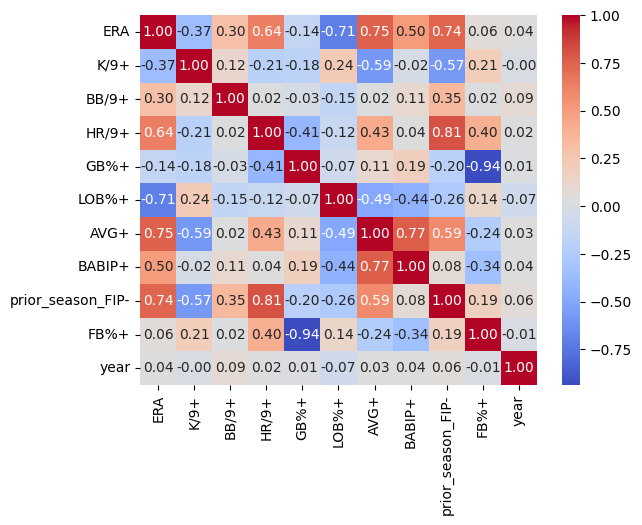

In [65]:
import seaborn as sns
modeling_options = stats[['ERA', 'K/9+', 'BB/9+', 'HR/9+', 'GB%+', 'LOB%+', 'AVG+', 'BABIP+', 'prior_season_FIP-', 'FB%+', 'year']]
matrix = modeling_options.corr()

sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f")

## Correlation Matrix Obserbations
  - ERA is highly Correlated with most other features which needs to be monitored. Especially it's relationship with HR/9+, LOB%+, AVG+.

  - GB%+ and FB%+ are extremely correlated as you could expect. For this reason we will need to drop one of those features

  - AVG+ has very high multicolinearity with high correlations to ERA, k/9+, BABIP+
  

## Step 4 - Selecting Base Modeling Set

From inspecting the Correlation Matrix we have narrowed down the feature set:


*   ERA: Good representative of performance. Must monitor the multicolinearity
*   K/9+: One of the main features of FIP is a players strike out rate. Likely to be and extremely important feature
*   BB/9+: Another feature which goes into the calculation of FIP and shows if a pitcher is wild.
*   HR/9+: Home run rate has a direct correlation to a players FIP. Can be a luck statistic so must monitor regression to the mean.
*   GB%+: Ground balls are important they usually at worst result in a single and have the chance of double plays.
*   LOB%+: Can be thought of a luck statistic but can be an important feature to model worse performance.
*   BABIP+: The more times pitchers allow hitters to put the ball in play.










In [66]:
MODEL_FEATURES = ['ERA', 'K/9+', 'BB/9+', 'HR/9+', 'GB%+', 'LOB%+','BABIP+',  'prior_season_FIP-', 'year']
TARGET = 'binary_fip-'

model_data = stats[MODEL_FEATURES + [TARGET]]
model_data.head()

,ERA,K/9+,BB/9+,HR/9+,GB%+,LOB%+,BABIP+,prior_season_FIP-,year,binary_fip-
0,2.528701,142.796554,62.904200,85.757958,77.922406,111.121617,90.626928,63.961433,2018,1
1,2.523364,143.712287,48.852962,96.661170,68.534923,117.701978,92.323447,67.446030,2018,1
2,2.875208,146.105159,90.267146,70.066138,84.781474,107.514357,97.080876,65.513920,2018,1
3,1.700461,130.204422,57.695811,37.916093,105.587487,112.085527,96.314515,49.275632,2018,1
4,3.150000,129.192806,65.321697,61.708446,110.244202,102.151775,103.603837,61.793765,2018,1


## Step 5 - Train/Validate/Test

The model will be trained on data from 2018-2022. The validation set will consist of data from 2023 and the test set will contain data from 2024.

In [67]:
train = model_data.loc[model_data['year'] < 2023]
validation = model_data.loc[model_data['year'] == 2023]
test = model_data.loc[model_data['year'] == 2024]

X_train = train.drop(columns=[TARGET] + ['year'])
y_train = train[TARGET]
X_validate = validation.drop(columns=[TARGET] + ['year'])
y_validate = validation[TARGET]
X_test = test.drop(columns=[TARGET] + ['year'])
y_test = test[TARGET]

print(len(X_train))
print(len(X_validate))
print(len(X_test))

print("Set target positive make-up")
print((y_train.sum()/ len(y_train)) * 100)
print((y_validate.sum()/ len(y_validate)) * 100)
print((y_test.sum()/ len(y_test)) * 100)

837
323
315
Set target positive make-up
61.648745519713266
53.56037151702786
58.0952380952381


## Train/Validate/Test Set analysis

The training data is made up of 837 Players and has a 61% rate of high performing pitchers. The validation set has 323 pitchers with a 53% high performing pitcher rate. Lastly the test set has a 58% high performing pitcher rate

## Step 6 - Baseline Model

For this project we are establishing the baseline by predicting next seasons FIP- using the prior seasons FIP- value. This provides a great baseline and provides some understanding of the correlation between prior season performance and performance for the next season.

In [68]:
from sklearn.metrics import roc_auc_score

baseline_auc = roc_auc_score(y_test, -X_test['prior_season_FIP-'])
print(f"Naive baseline AUC: {baseline_auc:.4f}")

Naive baseline AUC: 0.6721


## Baseline AUC interpretation

The X_test FIP- value was turned negative so that higher values would correspond to an increased likelihood of a positive predition in order to ensure AUC score is interpretable. The Baseline AUC is .672 which means that when randomly selecting a positive and negative case the model correctly provides a higher probability to the positive case 67.2% of the time. Any model we build must exceed this meaningfully to justify the added complexity

In [69]:
X_train = X_train.drop(columns=['prior_season_FIP-'])
X_validate = X_validate.drop(columns=['prior_season_FIP-'])
X_test = X_test.drop(columns=['prior_season_FIP-'])

## Step 7 - Modeling

For this project we are going to use an XGBoost Classification model. This model was choosen because of it's ability to capture complex non linear relationships within the modeling features. We will use Grid Search Cross validation in order to find the best tuned model before conducting any further analysis

In [70]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import StratifiedKFold, GridSearchCV

model_weights = (len(y_train) - sum(y_train)) / sum(y_train)

xg_model = XGBClassifier(random_state=42, scale_pos_weight=model_weights)

xg_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, .05, .1, .3],
    'max_depth': [3, 5, 7]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xg_grid = GridSearchCV(xg_model, param_grid=xg_params, scoring='roc_auc', cv=cv)

xg_grid.fit(X_train, y_train)

y_hat = xg_grid.predict(X_validate)
y_hat_proba = xg_grid.predict_proba(X_validate)[:,1]

print(f"Model parameters: {xg_grid.best_params_}")
print(f"ROC AUC Score: {roc_auc_score(y_validate, y_hat_proba)}")
print(f"Classification Report:\n{classification_report(y_validate, y_hat)}")

Model parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
ROC AUC Score: 0.6940655105973025
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.65      0.63       150
           1       0.68      0.64      0.66       173

    accuracy                           0.64       323
   macro avg       0.64      0.64      0.64       323
weighted avg       0.65      0.64      0.64       323



## Model Performance Analysis on Validation Set

*   XGBoost model parameters: Learning rate: 0.01, max_depth = 3, n_estimators =200
*   AUC Score: .694
*   Class 0 Precision: .61
*   Class 0 Recall: .65
*   Class 1 Precision: .68
*   Class 1 Recall: .64
*   Class 0 F1: .63
*   Class 1 F1: .66

The model provides a slight increase from the baseline for the AUC score. This increase in itself is not significant enough to justify the increased complexity. The increase means that the model is around 2% better at differentiating positive and negative predictions. Overall the model performs very similar on both classes having a slightly better performance on positive cases.





## Step 8 - Shap Analysis

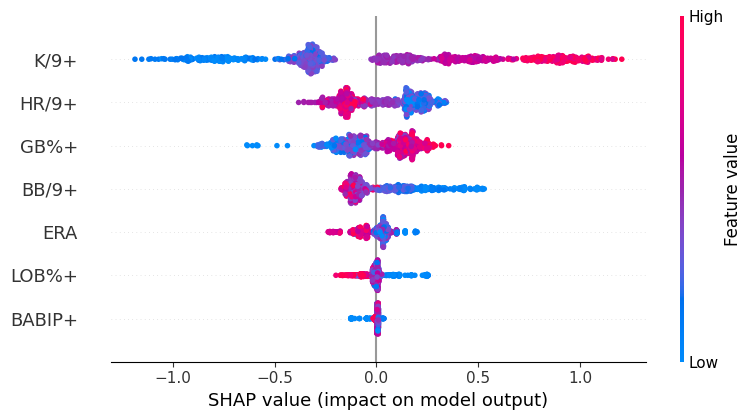

In [71]:
import shap

explainer = shap.TreeExplainer(xg_grid.best_estimator_)
shap_values = explainer(X_train)

shap.summary_plot(shap_values, X_train)

## Shap Analysis

The model important modeling features from the SHAP analysis are K/9+, HR/9+ and GB%+. It seems that K/9+ is likely the first split within the model and is therefore taking the largest impact which doesn't leave much for the other features. HR/9+ is showing a very strange relationship with features near the middle having the largest impact and extreme values having less impact. This is a common symptom of regression to the mean. What this means is that pitchers with extreme HR/9+ mostly had unlucky seasons where things didn't go right for them. Then the next season there statistics drop closer to where they would be on a regular basis which is whats causing the highest HR/9+ values to have less of a negative affect on the predictions than the middel values. The gaps within Shap values are also not something to worry about and simply mark splitting points within the trees since we are using an XGBoost model.

From the Shap analysis I have also decided to retrain the model without BABIP+. You can see the feature does not have an impact on the prediction with all shap values being very close to 0. Leaving features with no impact increases both the complexity and noise within the model so the feature should be removed.

In [72]:
X_train = X_train.drop(columns=['BABIP+'])
X_validate = X_validate.drop(columns=['BABIP+'])
X_test = X_test.drop(columns=['BABIP+'])

## Step 8 - Train updated Model

In [73]:
xg_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, .05, .1, .3],
    'max_depth': [3, 5, 7]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xg_grid = GridSearchCV(xg_model, param_grid=xg_params, scoring='roc_auc', cv=cv)

xg_grid.fit(X_train, y_train)

y_hat = xg_grid.predict(X_validate)
y_hat_proba = xg_grid.predict_proba(X_validate)[:,1]

print(f"Model parameters: {xg_grid.best_params_}")
print(f"ROC AUC Score: {roc_auc_score(y_validate, y_hat_proba)}")
print(f"Classification Report:\n{classification_report(y_validate, y_hat)}")

Model parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
ROC AUC Score: 0.6954720616570327
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.65      0.63       150
           1       0.68      0.66      0.67       173

    accuracy                           0.65       323
   macro avg       0.65      0.65      0.65       323
weighted avg       0.65      0.65      0.65       323



## Model Observations

The removal of BABIP+ did not have much of an impact on the model performance for the validation set. This is to be expected since the feature didn't have much of an impact on the prediction. The AUC increased from .694 to .695 which is a very small increase and still outperforms the Naive benchmark which scored a AUC of .672.

## Step 9 - Inspect New Shap Values

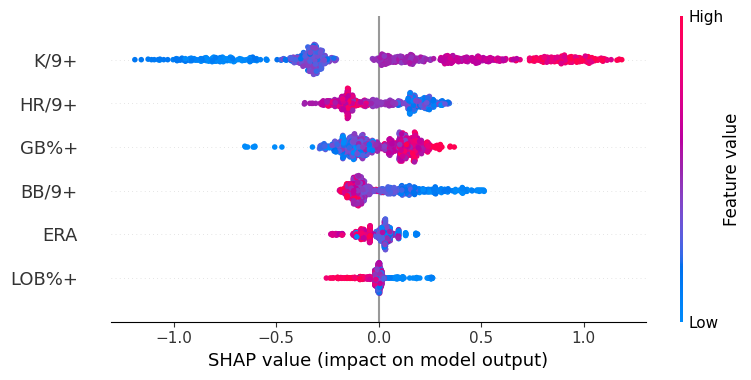

In [74]:
explainer = shap.TreeExplainer(xg_grid.best_estimator_)
shap_values = explainer(X_train)

shap.summary_plot(shap_values, X_train)

## Shap Inspection

The shap values look almost identical to the previous model run. It's important to note the asymetric signal for BB/9+. Extremely low values have strong impacts within the model where as High and medium values have very similar impacts. Once again this is a story of regression to the mean. For GB%+ there is a lack of seperation between the values and you can see some outliers on both ends this likely shows the learned thresholds from the model where it has picked up on extreme values having high impact on next season performance where as values close to the mean do not mean much for pitcher performance for the next season.

## Step 10 - Partial Dependency Plot(PDP) Inspection

Inspecting the PDP plots for the 3 most influential features from the SHAP analysis. These features are K/9+, HR/9+, and GB%+. The PDP plot allows you to get a better understand of how specific values for each feature affect the predictions. They also allow you to get a good understanding of splits which the model learned. The PDP takes the average prediction for the values so it can mask underlying relationships.

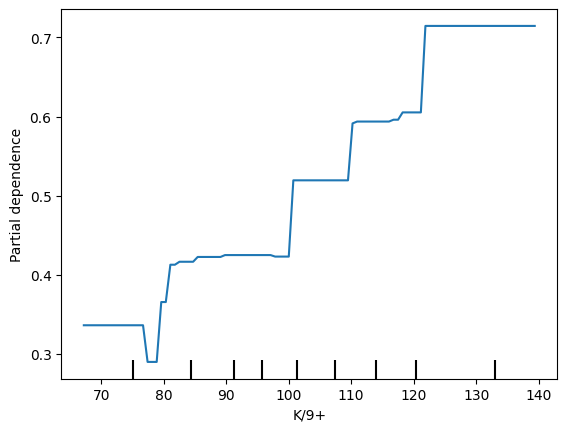

In [75]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(xg_grid, X_validate, features=[('K/9+')])

## K/9+ PDP Analysis

The PDP plot for K/9+ shows that as the K/9+ value increases so does the probability that a pitcher will perform well. This is exactly the kind of relationship which we expected. You can also see the modeling splits very well with K/9+ over around 125 being the highest modeling split. There is a large dip in model probability around K/9+ of 76-78 due to sparse data within those sections. It's also important to not fully trust specific sections like K/9+ around 70 where there are very few real pitchers

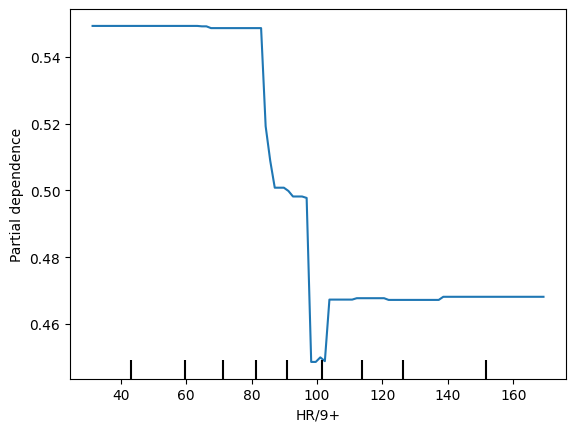

In [76]:
PartialDependenceDisplay.from_estimator(xg_grid, X_validate, features=[('HR/9+')])

## HR/9+ PDP Anaysis

The PDP plot for HR/9+ shows a very interesting relationship and shows that deviation within the HR/9+ value doesn't have much of an affect on the pitchers performance within certain thresholds. A HR/9+ from 40 to a little over 80 does not change the probability at all which means values between there can be thought of as the same. Once the pitcher reachs a value a little over 80 there is a significant drop in the liklihood of high performance and the drop continue until around 100 HR/9+ which is the mean value of pitchers throughout the league. You can see the model things pitchers over 100 are likely to perform better then next season than pitchers at 100. This is the regression to the mean where the model has picked up on the pattern that large HRs given up have a lot more to do with luck and certain situations than the actual pitcher.

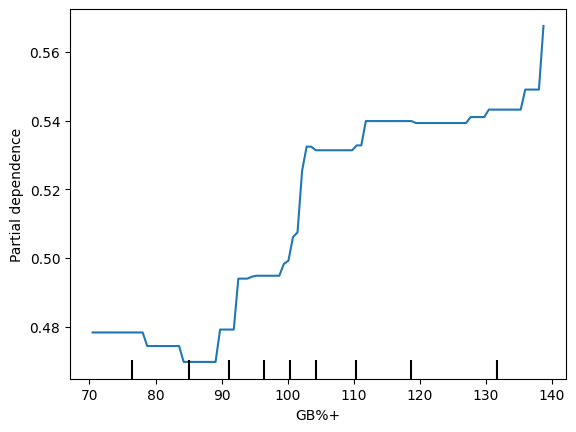

In [77]:
PartialDependenceDisplay.from_estimator(xg_grid, X_validate, features=[('GB%+')])

## GB%+ PDP Analysis

The Ground ball PDP shows a good relationship between the GB%+ and the pitchers performance in the next season this is largely due to the fact that some pitchers are ground ball pitchers because of there pitching arsinal. Higher Ground ball % is associated with better pitching performance. The large amount of staircase movement means the model found a lot of meaningful thresholds within the data. It's also important to understand that ground balls are highly correlated with specific pitching styles which means GB % is also largely associated with other statistics which means PDP creates unrealistic pitcher profiles.

## Step 11 - K/9+ Individual Conditional Expectation Plot (ICE)

ICE plots allow you to inspect the dependence of the prediction on K/9+ for all samples seperately where as the PDP takes the mean. This is important because it allows you to see if there are any relationships or instability which is being hidden by the mean.

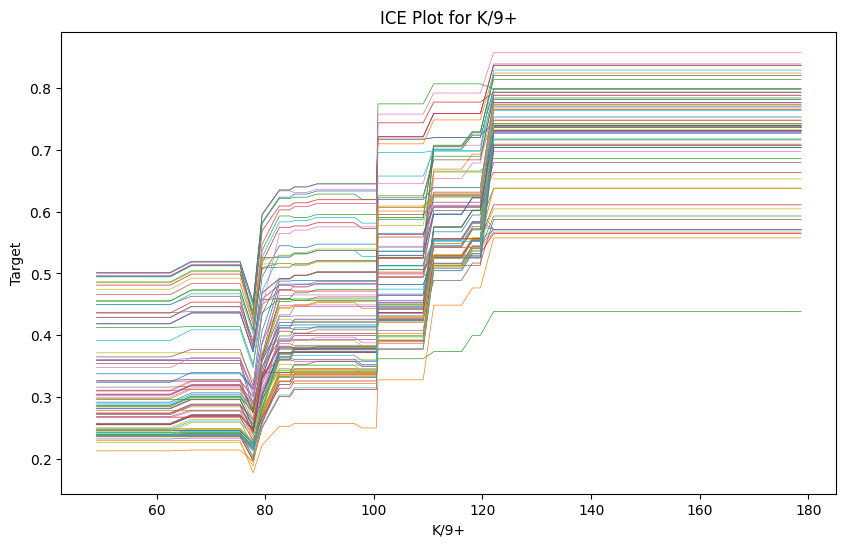

In [78]:
from pycebox.ice import ice, ice_plot
import matplotlib.pyplot as plt


def predict_fn(X):
  return xg_grid.predict_proba(X)[:,1]

feature = 'K/9+'
ice_data = ice(X_validate, feature, predict_fn, num_grid_points=50)

sampled_ice_data = ice_data.iloc[:, :100]

fig, ax = plt.subplots(figsize=(10, 6))
ice_plot(sampled_ice_data, frac_to_plot=1.0, ax=ax)

plt.title("ICE Plot for K/9+")
plt.xlabel("K/9+")
plt.ylabel("Target")

for line in ax.get_lines():
  line.set_linewidth(.5)

plt.show()

## K/9+ ICE Plot Analysis

The relationship between K/9+ which was found within the PDP plot holds you can see that almost all instances are followin the same pattern which was seen within the PDP plot. Looking further you can see there is a large variance when K/9+ is at 100 with probability values stretching from around .25 up to .75. This large variance shows that other features also play a large part in the prediction. At a little less that 80 K/9+ you can see that the variance largely decreases which means the model hit a specific split which is largely due to the sparse data within that section which causes the probability drop.


## Step 12 - Force Plot Analysis

Force plots allow you to look into how specific features impacted specific predictions. They are very good at diagnosing which features are causing modeling errors. In order to get a better understanding of errors we will select the most confident correct prediction, the most confident incorrect prediction, and a incertain predition from the model to see how the specific features are swaying the model. We will use the validation set for this excercise.

In [79]:
force_data = X_validate.copy()

force_data['actual'] = y_validate
force_data['probability'] = y_hat_proba

correct = force_data.loc[force_data['actual'] == 1].sort_values(by='probability', ascending=False).head(1)
wrong = force_data.loc[force_data['actual'] == 0].sort_values(by='probability', ascending=False).head(1)
middle = force_data.loc[(force_data['probability'] > .45) & (force_data['probability'] < .55)].head(1)


print(correct)
print(wrong)
print(middle)
correct.drop(columns=['actual', 'probability'], inplace=True)
wrong.drop(columns=['actual', 'probability'], inplace=True)
middle.drop(columns=['actual', 'probability'], inplace=True)

         ERA        K/9+      BB/9+    HR/9+        GB%+      LOB%+  actual  \
935  2.80083  128.457278  47.940123  36.6067  123.238921  94.107936       1   

     probability  
935     0.822296  
       ERA        K/9+       BB/9+      HR/9+        GB%+       LOB%+  actual  \
1108  2.97  135.254557  121.371167  66.003073  117.237394  103.173795       0   

      probability  
1108     0.776611  
          ERA        K/9+       BB/9+      HR/9+       GB%+      LOB%+  \
843  4.576271  122.319251  122.778038  78.918111  85.947758  96.449954   

     actual  probability  
843       1     0.548015  


In [80]:
shap.initjs()
shap_value = explainer.shap_values(correct)
shap.plots.force(explainer.expected_value, shap_value[0], correct.iloc[0])

## Correct Prediction Analysis

From the force plot you can see the most influential feature is K/9+ which increases the probability significantly followed behind BB/9+ and GB%+. All of these values make sense as you can see the pitcher performs well above league average in all of these metrics. You can see that the LOB% is having a negative affect on the pitchers probability which is a bit worrying and likely shows a modeling limiation in interpreting standed rate rather than a genuine negative signal about the pitcher.

In [81]:
shap.initjs()
shap_value = explainer.shap_values(wrong)
shap.plots.force(explainer.expected_value, shap_value[0], wrong.iloc[0])

## Incorrect Prediction Analysis

The incorrect prediction force plot is extremly insightful for how the model is weighting the features and what is causing this incorrect prediction. You can see that this pitcher performs well above league average in K/9, GB%, HR/9 and ERA. This is the reason the model predicted the player would have a good season but you can see that the pitchers BB/9 is 21% higher than the league average but the model doesn't think that statistic is very important and therfore does it doesn't significantly decrease the pitchers probability even though walk rates are not likely to be fixed significantly from one season it the next. The LOB% is not shown within the force plot because it didn't have much of an impact but it was 3% over the league average and this tells a bit of the story that the pitcher had a high walk rate but got away with it and most of those players where left on base. But in the next season the pitchers walk rate likely affected there stats more significantly.

In [82]:
shap.initjs()
shap_value = explainer.shap_values(middle)
shap.plots.force(explainer.expected_value, shap_value[0], middle.iloc[0])

## Uncertain Prediction Analysis

From this force plot you can understand why the model was a bit uncertain the player was well above average in K/9 and HR/9 but walked a lot of players, has a low ground ball percentage, and high ERA. The model predicted a .54 probability of performing will in the next season and the pitcher did have a FIP- below 100. You can see the K/9 was the main reason for the pitchers higher probability even though many of there other stats would suggest lower performance.

## Step 13 - SHAP vs Permutation Importance Analysis

In [83]:
X_validate.columns

Index(['ERA', 'K/9+', 'BB/9+', 'HR/9+', 'GB%+', 'LOB%+'], dtype='object')

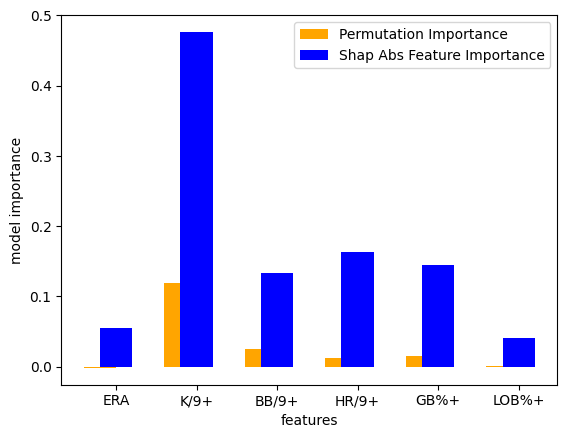

In [84]:
from sklearn.inspection import permutation_importance
import numpy as np


perm = permutation_importance(xg_grid, X_validate, y_validate, n_repeats=20, random_state=42, scoring='roc_auc').importances_mean

explainer = shap.TreeExplainer(xg_grid.best_estimator_)
shap_values = explainer.shap_values(X_validate)

abs_sv = np.abs(shap_values)
shap_feature_importance = np.mean(abs_sv, axis=(0))


x = np.arange(6)

plt.bar(x -.2, perm, .4,  color='orange')
plt.bar(x, shap_feature_importance, .4, color='blue')
plt.xticks(x, X_validate.columns)
plt.xlabel("features")
plt.ylabel("model importance")
plt.legend(["Permutation Importance", "Shap Abs Feature Importance"])
plt.show()

## SHAP Vs. Permutation Importance Analysis

From the chart you can see that both metrics agree that K/9+ is by far the most important statistic. The biggest difference between the two is that permutation importance suggests that BB/9+ is the the next most important feature by a pretty significant amount. This is likely due to the fact that BB/9+ matters a lot for a small number of pitchers. SHAP averages across everyone and makes it look unimportant. Permutation importance catches that it's critical for the edge cases that drive AUC.

## Step 14 - Test Results

In [85]:
y_hat_test = xg_grid.predict(X_test)
y_hat_test_proba = xg_grid.predict_proba(X_test)[:,1]

print(f"AUC: {roc_auc_score(y_test, y_hat_test_proba)}")
print(f"Classification Report:\n{classification_report(y_test, y_hat_test)}")

AUC: 0.6985221063089915
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.64      0.59       132
           1       0.71      0.63      0.66       183

    accuracy                           0.63       315
   macro avg       0.63      0.63      0.63       315
weighted avg       0.64      0.63      0.63       315



## Model Test Results Analysis
Metrics:
*   AUC: .698
*   Class 0 Precision: .55
*   Class 0 Recall: .64
*   Class 1 Precision: .71
*   Class 1 Recall: .63
*   Class 0 F1: .59
*   Class 1 F1: .66

The model performed slightly better than the Naive baseline model showing about a 2% increase in AUC. The model continues to perform better when predicting on players who did have a FIP- below 100 with a significantly higher F1 score. Overall the with the performance being marginally better than using the prior seasons FIP- the increased complexity did not prove worth it for raw prediction accuracy but is worth using in order to shorten the list of pitchers which should be consindered for offseason aquisition.


## Executive Memo - Pitcher Performance Prediction Model
**To:** General Manager

**From:** Analytics Team

From the modeling Excercise it has been concluded that using previous season statistics to predict whether a pitcher will have a above average FIP- doesn't provide a substantial enough increase in performance compared to simply using the prior season FIP-. The model achieved an AUC of 0.698 compared to a naive baseline of 0.672, representing a modest but meaningful improvement. Although there was not a large increase in accuracy the model can be used in order to filter players which are very likely to perform well in the next season. Because the model was not trained using prior season FIP- it will likely show players which might otherwise have been overlooked. The team recommends applying a probability threshold of .7 when extracting highly confident players from the model. From the anaylsis we have found that the most important statistics when predicting pitcher performance where K/9+, HR/9+ and GB%+ with K/9+ being by far the most important statistic. It's important to note that further exploration into the pitchers statistics is advised for example checking ther LOB%+ to see if the pitcher might have had luck on there side throughout the previous season and are likely to have a performance decline. The model also found that BB/9+ had a significant affect but only on a small subset of players where the stat was extremely low. Because BB/9+ impact is concentrated in elite walk suppressors, manually review walk rates for any pitcher the model flags as highly confident. The model is less reliable at identifying pitchers likely to decline, manual review is especially important before avoiding a pitcher based solely on a low model probability.

